In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ratings = pd.read_csv(
    r"C:\Users\danam\OneDrive\Desktop\ML_journey\project_02_movie_recommender\datasets\u.data",
    sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp']
)

In [3]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
ratings.shape

(100000, 4)

In [5]:
movies = pd.read_csv(
    r"C:\Users\danam\OneDrive\Desktop\ML_journey\project_02_movie_recommender\datasets\u.item",
    sep='|',
    encoding='latin-1',
    usecols=[0, 1],
    names=['movie_id', 'title'],
    header=None
)

In [6]:
movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [7]:
movies.shape

(1682, 2)

In [8]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [9]:
ratings.describe()

,user_id,movie_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [10]:
df = ratings.merge(movies, on='movie_id')

In [11]:
df.head()

,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [12]:
df.groupby('title')['rating'].count().sort_values(ascending=False)

title
Star Wars (1977)                      583
Contact (1997)                        509
Fargo (1996)                          508
Return of the Jedi (1983)             507
Liar Liar (1997)                      485
                                     ... 
Great Day in Harlem, A (1994)           1
Other Voices, Other Rooms (1997)        1
Good Morning (1971)                     1
Girls Town (1996)                       1
Á köldum klaka (Cold Fever) (1994)      1
Name: rating, Length: 1664, dtype: int64

In [13]:
df.groupby('title')['rating'].mean().sort_values(ascending=False)

title
They Made Me a Criminal (1939)                  5.0
Marlene Dietrich: Shadow and Light (1996)       5.0
Saint of Fort Washington, The (1993)            5.0
Someone Else's America (1995)                   5.0
Star Kid (1997)                                 5.0
                                               ... 
Eye of Vichy, The (Oeil de Vichy, L') (1993)    1.0
King of New York (1990)                         1.0
Touki Bouki (Journey of the Hyena) (1973)       1.0
Bloody Child, The (1996)                        1.0
Crude Oasis, The (1995)                         1.0
Name: rating, Length: 1664, dtype: float64

In [14]:
movie_stats = df.groupby('title')['rating'].agg(['count', 'mean'])

In [15]:
print(movie_stats)

                                       count      mean
title                                                 
'Til There Was You (1997)                  9  2.333333
1-900 (1994)                               5  2.600000
101 Dalmatians (1996)                    109  2.908257
12 Angry Men (1957)                      125  4.344000
187 (1997)                                41  3.024390
...                                      ...       ...
Young Guns II (1990)                      44  2.772727
Young Poisoner's Handbook, The (1995)     41  3.341463
Zeus and Roxanne (1997)                    6  2.166667
unknown                                    9  3.444444
Á köldum klaka (Cold Fever) (1994)         1  3.000000

[1664 rows x 2 columns]


In [16]:
popular_movies = movie_stats[movie_stats['count'] >= 50]

In [17]:
print(popular_movies)

                                     count      mean
title                                               
101 Dalmatians (1996)                  109  2.908257
12 Angry Men (1957)                    125  4.344000
2 Days in the Valley (1996)             93  3.225806
20,000 Leagues Under the Sea (1954)     72  3.500000
2001: A Space Odyssey (1968)           259  3.969112
...                                    ...       ...
Wolf (1994)                             67  2.701493
Wrong Trousers, The (1993)             118  4.466102
Wyatt Earp (1994)                       50  3.100000
Young Frankenstein (1974)              200  3.945000
Young Guns (1988)                      101  3.207921

[605 rows x 2 columns]


In [18]:
import seaborn as sns

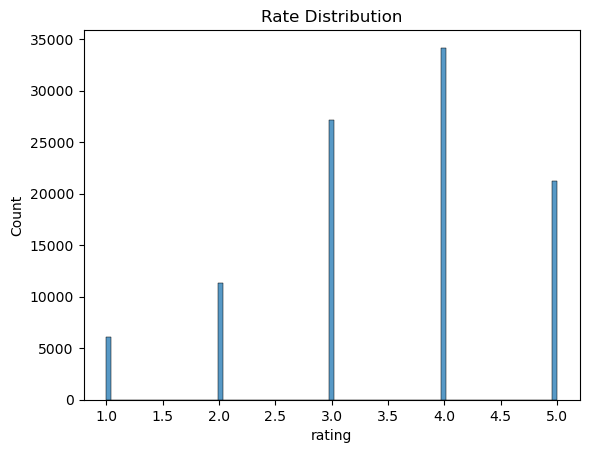

In [19]:
sns.histplot(data=df, x='rating')
plt.title('Rate Distribution')
plt.show()

In [20]:
top10 = movie_stats.sort_values('count', ascending = False).head(10)

In [21]:
print(top10)

                               count      mean
title                                         
Star Wars (1977)                 583  4.358491
Contact (1997)                   509  3.803536
Fargo (1996)                     508  4.155512
Return of the Jedi (1983)        507  4.007890
Liar Liar (1997)                 485  3.156701
English Patient, The (1996)      481  3.656965
Scream (1996)                    478  3.441423
Toy Story (1995)                 452  3.878319
Air Force One (1997)             431  3.631090
Independence Day (ID4) (1996)    429  3.438228


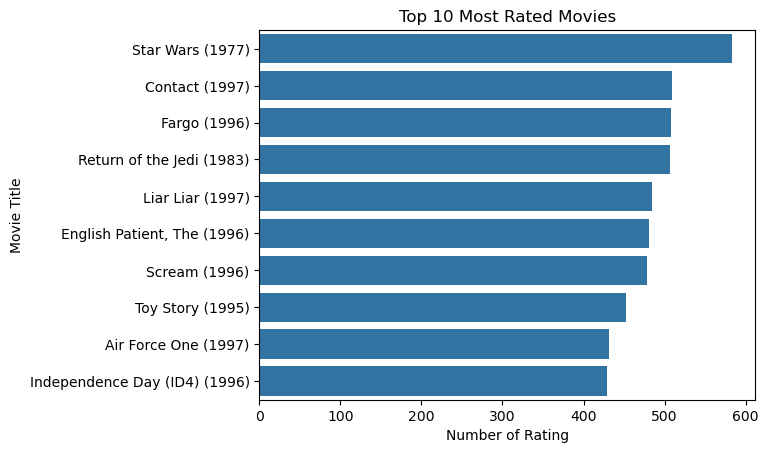

In [22]:
sns.barplot(data=top10, x='count', y='title')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Rating')
plt.ylabel('Movie Title')
plt.show()

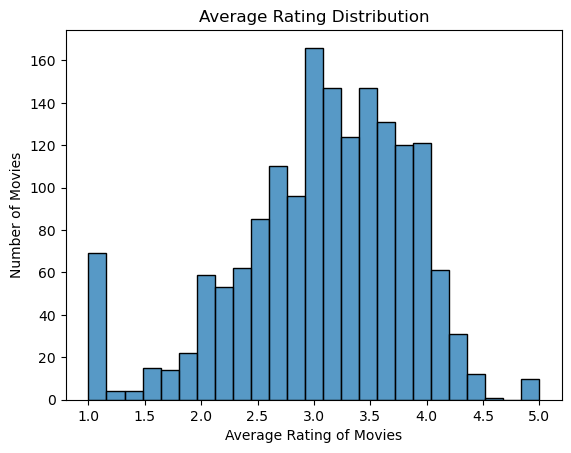

In [23]:
sns.histplot(data=movie_stats, x='mean')
plt.title('Average Rating Distribution')
plt.xlabel('Average Rating of Movies')
plt.ylabel('Number of Movies')
plt.show()

In [24]:
user_movie_matrix = df.pivot_table(
    index= 'user_id',
    columns= 'title',
    values= 'rating'
)

In [25]:
user_movie_matrix.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,4.0,NaN


In [26]:
user_movie_matrix.shape

(943, 1664)

In [27]:
user_movie_matrix = user_movie_matrix.fillna(0)

In [28]:
user_movie_matrix.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,2.0,5.0,0.0,0.0,3.0,4.0,0.0,0.0,...,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0


In [29]:
from sklearn.metrics.pairwise import cosine_similarity

In [30]:
user_similarity = cosine_similarity(user_movie_matrix)

In [31]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index= user_movie_matrix.index,
    columns= user_movie_matrix.index
)

In [32]:
user_similarity_df.head()  

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.168937,0.048388,0.064561,0.379670,0.429682,0.443097,0.320079,0.078385,0.377733,...,0.372213,0.119860,0.269860,0.193343,0.197949,0.118722,0.315064,0.149086,0.181612,0.399432
2,0.168937,1.000000,0.113393,0.179694,0.073623,0.242106,0.108604,0.104257,0.162470,0.161273,...,0.147095,0.310661,0.363328,0.410725,0.322713,0.231096,0.228793,0.162911,0.175273,0.106732
3,0.048388,0.113393,1.000000,0.349781,0.021592,0.074018,0.067423,0.084419,0.062039,0.066217,...,0.033885,0.043453,0.167140,0.071288,0.126278,0.026758,0.164539,0.102899,0.136757,0.026990
4,0.064561,0.179694,0.349781,1.000000,0.031804,0.068431,0.091507,0.188060,0.101284,0.060859,...,0.054615,0.036784,0.133619,0.196561,0.146058,0.030202,0.196858,0.152041,0.171538,0.058752
5,0.379670,0.073623,0.021592,0.031804,1.000000,0.238636,0.374733,0.248930,0.056847,0.201427,...,0.340183,0.080580,0.095284,0.081053,0.148607,0.071612,0.239955,0.139595,0.153799,0.313941


In [35]:
def get_recommendations(user_id, n_recommendations=5):
    
    # Step 1: Get similarity scores of our user with all other users
    # Sort from highest similarity to lowest
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    
    # Step 2: Remove the user themselves
    # Because similarity with yourself = 1.0 (not useful!)
    similar_users = similar_users.drop(user_id)
    
    # Step 3: Take only top 10 most similar users
    # More similar users = better recommendations!
    similar_users = similar_users.head(10)
    
    # Step 4: Get movies that similar users watched and rated
    # loc[] gets specific rows from matrix using user IDs
    similar_users_movies = user_movie_matrix.loc[similar_users.index]

    # Step 5: Get movies our user has NOT watched yet
    # Where rating = 0.0 mean not watched
    user_watched = user_movie_matrix.loc[user_id]
    user_unwatched = user_watched[user_watched == 0.0].index

    # Sp 6: Calculate average rating for unwatched movies
    # Only from similar user rating
    movie_scores = similar_users_movies[user_unwatched].mean() 

    # Step 7: Sort movies by score and return top N
    # ascending=False = highest score first!
    recommendations = movie_scores.sort_values(ascending=False).head(n_recommendations)

    return recommendations

#  Find all users similar to me

#  Remove myself

#  Keep only top 10 similar users

#  See what movies they watched

#  Find movies I HAVEN'T watched

#  Score each unwatched movie

   by how similar users rated it

#  Return top 5 highest scored movies!

In [34]:
get_recommendations(1)

title
Schindler's List (1993)                                                        4.1
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)    3.9
Stand by Me (1986)                                                             3.7
E.T. the Extra-Terrestrial (1982)                                              3.7
One Flew Over the Cuckoo's Nest (1975)                                         3.7
dtype: float64

In [41]:
movies_genres = pd.read_csv(
     r"C:\Users\danam\OneDrive\Desktop\ML_journey\project_02_movie_recommender\datasets\u.item",
    sep='|',
    encoding='latin-1',
    header=None,
    names=['movie_id', 'title', 'release_date', 'video_release', 
           'url', 'unknown', 'Action', 'Adventure', 'Animation',
           'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
           'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
           'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
)

In [42]:
movies_genres.head(5)

,movie_id,title,release_date,video_release,url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [43]:
movies_genres = movies_genres.drop(columns=['release_date', 'video_release', 'url'])

In [44]:
movies_genres.head(5)

,movie_id,title,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [45]:
movies_genres = movies_genres.set_index('title')

In [46]:
movies_genres.head()

,movie_id,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
title,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
GoldenEye (1995),2,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
Four Rooms (1995),3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
Get Shorty (1995),4,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
Copycat (1995),5,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [47]:
movies_genres = movies_genres.drop(columns=['movie_id', 'unknown'])

In [52]:
movie_similarity = cosine_similarity(movies_genres)

In [62]:
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movies_genres.index,
    columns=movies_genres.index

)

In [63]:
movie_similarity_df.head()

title,Toy Story (1995),GoldenEye (1995),Four Rooms (1995),Get Shorty (1995),Copycat (1995),Shanghai Triad (Yao a yao yao dao waipo qiao) (1995),Twelve Monkeys (1995),Babe (1995),Dead Man Walking (1995),Richard III (1995),...,Mirage (1995),Mamma Roma (1962),"Sunchaser, The (1996)","War at Home, The (1996)",Sweet Nothing (1995),Mat' i syn (1997),B. Monkey (1998),Sliding Doors (1998),You So Crazy (1994),Scream of Stone (Schrei aus Stein) (1991)
title,,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),1.000000,0.000000,0.00000,0.333333,0.000000,0.00000,0.000000,0.666667,0.00000,0.000000,...,0.000000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.57735,0.00000
GoldenEye (1995),0.000000,1.000000,0.57735,0.333333,0.333333,0.00000,0.000000,0.000000,0.00000,0.000000,...,0.816497,0.00000,0.00000,0.00000,0.00000,0.00000,0.408248,0.000000,0.00000,0.00000
Four Rooms (1995),0.000000,0.577350,1.00000,0.000000,0.577350,0.00000,0.000000,0.000000,0.00000,0.000000,...,0.707107,0.00000,0.00000,0.00000,0.00000,0.00000,0.707107,0.000000,0.00000,0.00000
Get Shorty (1995),0.333333,0.333333,0.00000,1.000000,0.333333,0.57735,0.408248,0.666667,0.57735,0.408248,...,0.408248,0.57735,0.57735,0.57735,0.57735,0.57735,0.000000,0.408248,0.57735,0.57735
Copycat (1995),0.000000,0.333333,0.57735,0.333333,1.000000,0.57735,0.408248,0.333333,0.57735,0.408248,...,0.408248,0.57735,0.57735,0.57735,0.57735,0.57735,0.408248,0.408248,0.00000,0.57735


In [74]:
def get_content_recommendations(movie_title, n=5):
    
    # Step 1: Get similarity scores for the given movie
    # movie_title = input movie name
    # Gets that movie's column from similarity matrix
    # Shows how similar every other movie is to it!
    similar_movies = movie_similarity_df[movie_title].sort_values(ascending=False)
    
    # Step 2: Remove the movie itself
    # Because movie vs itself = 1.0 (not useful!)
    similar_movies = similar_movies.drop(movie_title)
    
    # Step 3: Return top N most similar movies
    # Default = 5 recommendations
    similar_movies = similar_movies.head(n)
    
    return similar_movies

In [75]:
print(get_content_recommendations('Toy Story (1995)'))

title
Aladdin and the King of Thieves (1996)    1.000000
Aladdin (1992)                            0.866025
Goofy Movie, A (1995)                     0.866025
Jungle2Jungle (1997)                      0.816497
Angels in the Outfield (1994)             0.816497
Name: Toy Story (1995), dtype: float64


In [90]:
def hybrid_recommendations(user_id, movie_title, n=5):
    
    # Step 1: Get collaborative recommendations
    collab_score = get_recommendations(user_id)
    
    # Step 2: Get content based recommendations
    content_score = get_content_recommendations(movie_title)

    # Step 3: Combine both scores
    # Add collaborative and content scores together
    # Movies in both lists get boosted score!
    combined_score = collab_score.add(content_score, fill_value=0)

    # Step 4: Sort by combined score highest first
    # Return top N recommendations
    combined_score = combined_score.sort_values(ascending=False)
    
    return combined_score.head(n)

In [91]:
print(hybrid_recommendations(1, 'Toy Story (1995)'))

title
Schindler's List (1993)                                                        4.1
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)    3.9
E.T. the Extra-Terrestrial (1982)                                              3.7
One Flew Over the Cuckoo's Nest (1975)                                         3.7
Stand by Me (1986)                                                             3.7
dtype: float64
